In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

In [2]:
csv_path = 'data/archive/HAM10000_metadata.csv'
skin_df = pd.read_csv(csv_path)
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


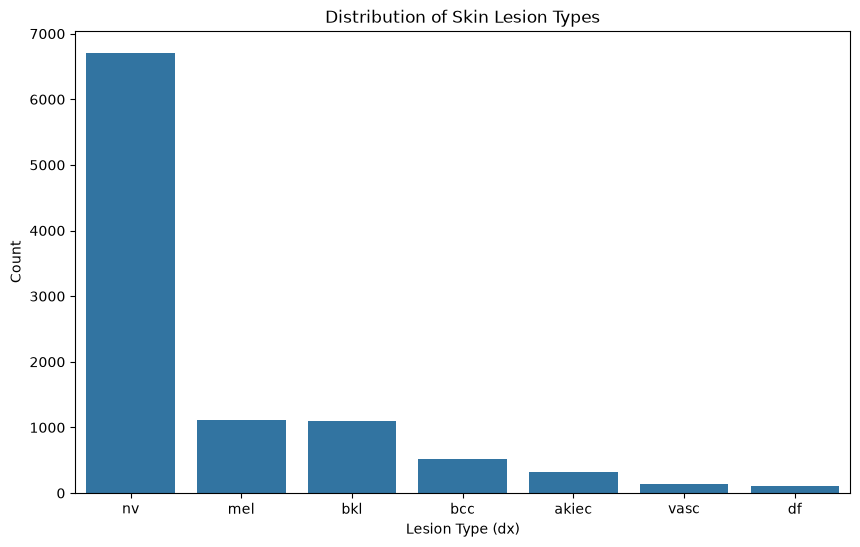

In [3]:
# Print the exact count of each lesion type (the 'dx' column stands for diagnosis)
print(skin_df['dx'].value_counts())

# Plotting the distribution as a bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x='dx', data=skin_df, order=skin_df['dx'].value_counts().index)
plt.title('Distribution of Skin Lesion Types')
plt.xlabel('Lesion Type (dx)')
plt.ylabel('Count')
plt.show()

In [4]:
import os
from glob import glob

# Search for every .jpg file inside your 'data' folder (and any subfolders).
image_path_list = glob(os.path.join('data', 'archive', '**', '*.jpg'), recursive=True)

# Creating a dictionary that links the image's base name to its full path.
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_path_list}
skin_df['path'] = skin_df['image_id'].map(image_path_dict.get)
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data\archive\HAM10000_images_part_1\ISIC_00274...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data\archive\HAM10000_images_part_1\ISIC_00250...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data\archive\HAM10000_images_part_1\ISIC_00267...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data\archive\HAM10000_images_part_1\ISIC_00256...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data\archive\HAM10000_images_part_2\ISIC_00316...


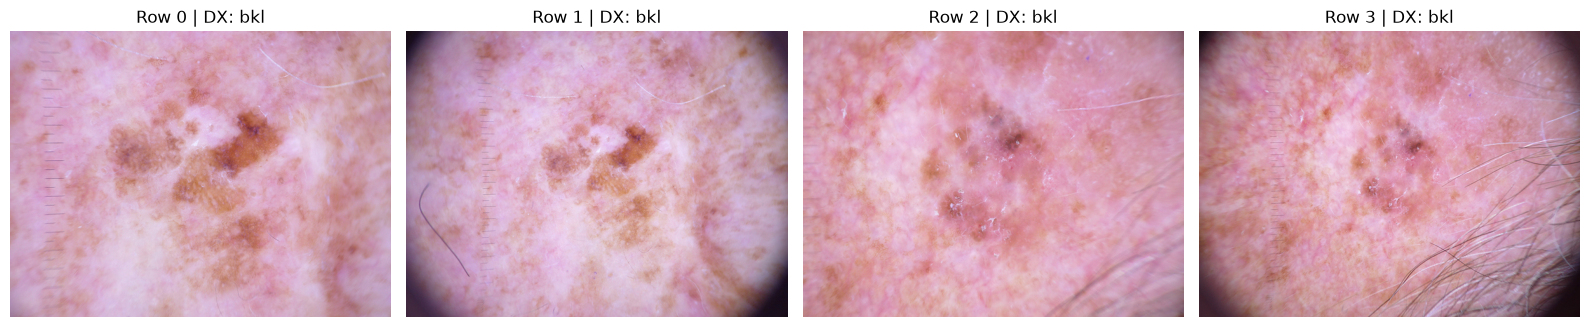

In [5]:
from PIL import Image

# Creating a wide figure to hold 4 images side-by-side
plt.figure(figsize=(16, 4))

# Loop through the first 4 rows (index 0, 1, 2, 3)
for i in range(4):
    # Extract the file path and the diagnosis code for the current row
    img_path = skin_df['path'][i]
    diagnosis = skin_df['dx'][i]
    
    # Open the image
    img = Image.open(img_path)
    
    # Creating a subplot 
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis('off') 
    plt.title(f"Row {i} | DX: {diagnosis}")

# Adjust spacing and display the grid
plt.tight_layout()
plt.show()